# ST1504 Deep Learning — CA2 Part A: Image Generation with GAN/VAE on CIFAR-10

**Module:** ST1504 Deep Learning &nbsp;|&nbsp; **Course:** DAAA &nbsp;|&nbsp; **Semester:** AY2026/27 Semester 1

**Team Members:** *Ephraim, P2510666* and *Han Qian, P2508526* and *Zheng Hao, P2510848*


In [2]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 and normalize to [0, 1]
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print(f"X_train_norm: {X_train_norm.shape}, X_test_norm: {X_test_norm.shape}")

X_train_norm: (50000, 32, 32, 3), X_test_norm: (10000, 32, 32, 3)


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ---------- Sampling layer (standard reparameterization trick) ----------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# ---------- Architecture definitions (must match training exactly) ----------
latent_dim = 64  # must match what was used during training

def build_encoder_decoder():
    encoder_inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
    x = layers.Reshape((2, 2, 512))(x)
    x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
    return encoder, decoder


class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type="mse", ssim_weight=0.5, edge_weight=10.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        self.ssim_weight = ssim_weight
        self.edge_weight = edge_weight
        self.beta = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def pixel_loss(self, data, reconstruction):
        return tf.reduce_mean(
            tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1, 2))
        )

    def edge_loss(self, data, reconstruction):
        data_edges = tf.image.sobel_edges(data)
        recon_edges = tf.image.sobel_edges(reconstruction)
        return tf.reduce_mean(tf.abs(data_edges - recon_edges))

    def compute_reconstruction_loss(self, data, reconstruction):
        px_loss = self.pixel_loss(data, reconstruction)
        ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(data, reconstruction, max_val=1.0))
        total = (1 - self.ssim_weight) * px_loss + self.ssim_weight * ssim_loss
        edge = self.edge_loss(data, reconstruction)
        total = total + self.edge_weight * edge
        return total

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.compute_reconstruction_loss(data, reconstruction)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "beta": self.beta,
        }


# ---------- Rebuild model + load saved weights (no training) ----------
encoder, decoder = build_encoder_decoder()
vae = VAE(encoder, decoder, loss_type="mse", ssim_weight=0.8, edge_weight=0.6)

_ = vae(X_test_norm[:1])          # build the model so weight shapes exist
vae.load_weights("cvae_cifar10_final.weights.h5")
print("Weights loaded successfully.")

Weights loaded successfully.


(1000, 32, 32, 3)
unique pairs used: 1000
all pairs same class: True
class 0: 91 images
class 1: 109 images
class 2: 89 images
class 3: 87 images
class 4: 107 images
class 5: 108 images
class 6: 98 images
class 7: 113 images
class 8: 88 images
class 9: 110 images


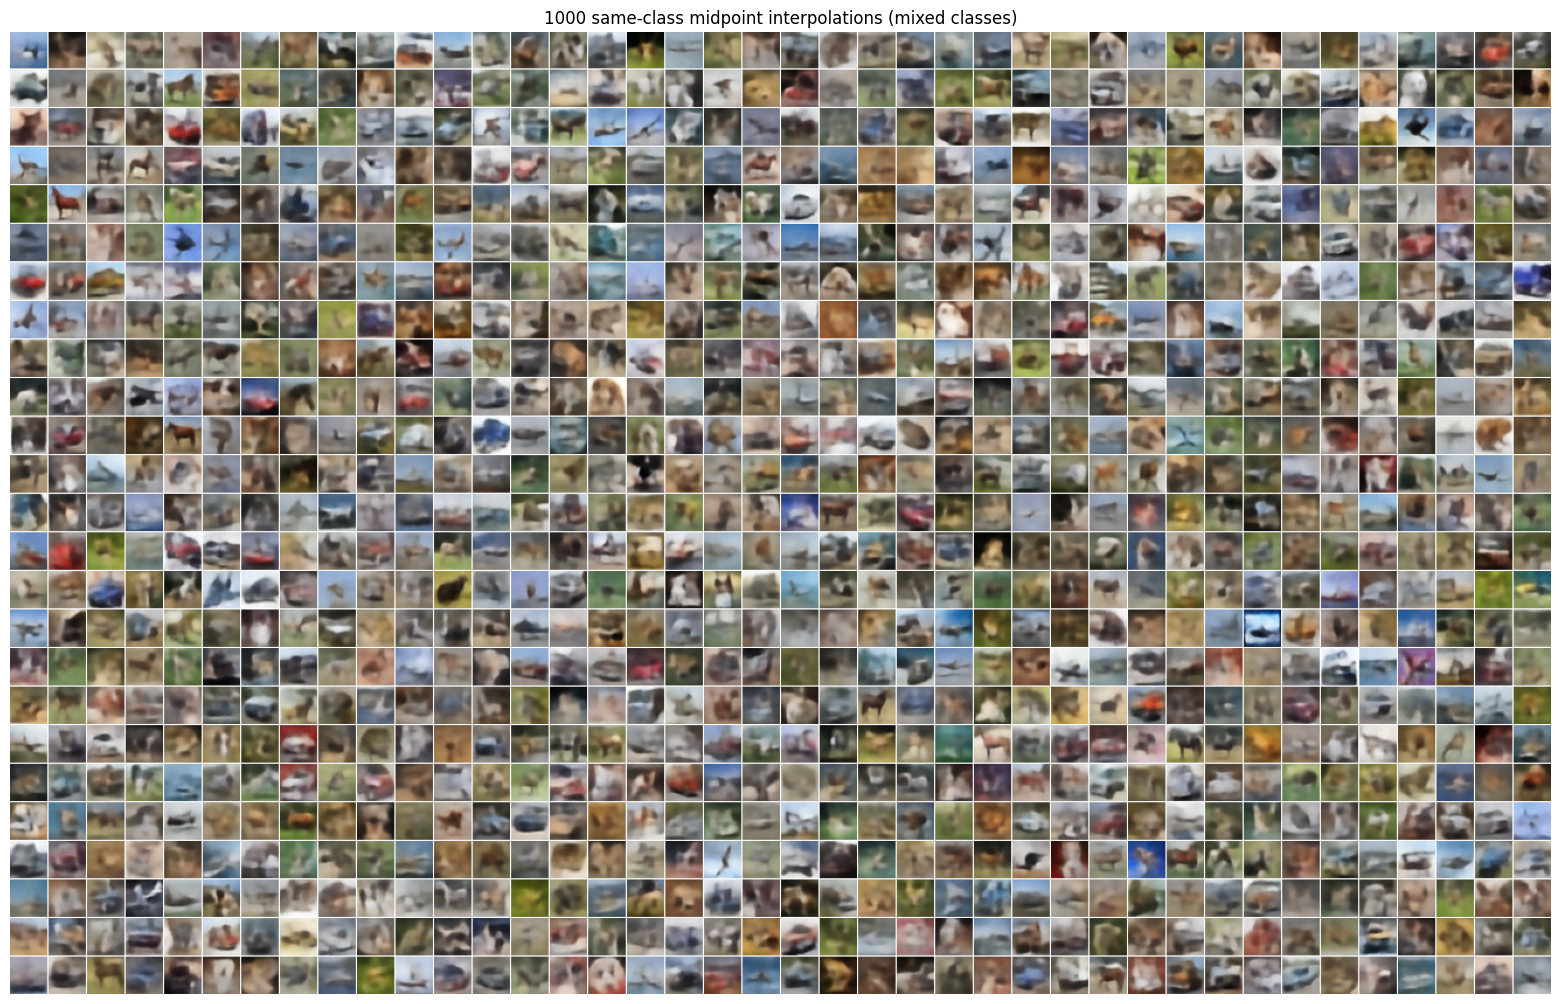

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def generate_midpoint_images_unique(vae, x_data, y_data, class_label=None,
                                     n_images=1000, img_size=32, channels=3, seed=None):
    rng = np.random.default_rng(seed)
    y_flat = y_data.squeeze()

    idx1 = np.empty(n_images, dtype=int)
    idx2 = np.empty(n_images, dtype=int)
    used_pairs = set()

    if class_label is not None:
        pool = np.where(y_flat == class_label)[0]
        max_possible = len(pool) * (len(pool) - 1) // 2
        if n_images > max_possible:
            raise ValueError(f"Only {max_possible} unique pairs possible for class "
                              f"{class_label}, but {n_images} were requested.")
        count = 0
        while count < n_images:
            i, j = rng.choice(pool, size=2, replace=False)
            key = (min(i, j), max(i, j))
            if key in used_pairs:
                continue
            used_pairs.add(key)
            idx1[count], idx2[count] = i, j
            count += 1
    else:
        classes = np.unique(y_flat)
        count = 0
        while count < n_images:
            c = rng.choice(classes)
            pool = np.where(y_flat == c)[0]
            if len(pool) < 2:
                continue
            i, j = rng.choice(pool, size=2, replace=False)
            key = (min(i, j), max(i, j))
            if key in used_pairs:
                continue
            used_pairs.add(key)
            idx1[count], idx2[count] = i, j
            count += 1

    z1, _, _ = vae.encoder.predict(x_data[idx1], batch_size=256, verbose=0)
    z2, _, _ = vae.encoder.predict(x_data[idx2], batch_size=256, verbose=0)
    z_mid = (z1 + z2) / 2.0

    generated = vae.decoder.predict(z_mid, batch_size=256, verbose=0)
    generated = np.clip(generated.reshape(-1, img_size, img_size, channels), 0, 1)

    return generated, idx1, idx2


def make_image_grid(images, n_cols=40, padding=1):
    n_images = images.shape[0]
    n_rows = int(np.ceil(n_images / n_cols))
    img_h, img_w, c = images.shape[1:]
    grid_h = n_rows * (img_h + padding) - padding
    grid_w = n_cols * (img_w + padding) - padding
    grid = np.ones((grid_h, grid_w, c))
    for idx in range(n_images):
        row, col = divmod(idx, n_cols)
        y0, x0 = row * (img_h + padding), col * (img_w + padding)
        grid[y0:y0 + img_h, x0:x0 + img_w, :] = images[idx]
    return grid


# --- run it: 1000 midpoint-interpolated images, mixed classes (same-class pairs) ---
generated_imgs, idx1, idx2 = generate_midpoint_images_unique(
    vae, X_train_norm, y_train, class_label=None, n_images=1000, seed=42
)
print(generated_imgs.shape)
print("unique pairs used:", len(set(zip(np.minimum(idx1, idx2), np.maximum(idx1, idx2)))))

y_flat = y_train.squeeze()
same_class_check = (y_flat[idx1] == y_flat[idx2])
print("all pairs same class:", same_class_check.all())

classes_used = y_flat[idx1]
unique, counts = np.unique(classes_used, return_counts=True)
for u, c in zip(unique, counts):
    print(f"class {u}: {c} images")

grid = make_image_grid(generated_imgs, n_cols=40)
plt.figure(figsize=(20, 12.5))
plt.imshow(grid)
plt.axis('off')
plt.title(f"{generated_imgs.shape[0]} same-class midpoint interpolations (mixed classes)")
plt.show()

In [6]:
import tensorflow as tf

# --- 1. Blend quality: is each generated image similar to BOTH its parents? ---
parent1_imgs = X_train_norm[idx1]
parent2_imgs = X_train_norm[idx2]

ssim_to_parent1 = tf.image.ssim(
    tf.convert_to_tensor(generated_imgs, dtype=tf.float32),
    tf.convert_to_tensor(parent1_imgs, dtype=tf.float32), max_val=1.0
).numpy()
ssim_to_parent2 = tf.image.ssim(
    tf.convert_to_tensor(generated_imgs, dtype=tf.float32),
    tf.convert_to_tensor(parent2_imgs, dtype=tf.float32), max_val=1.0
).numpy()

print(f"Mean SSIM to parent 1: {ssim_to_parent1.mean():.4f}")
print(f"Mean SSIM to parent 2: {ssim_to_parent2.mean():.4f}")
print(f"Balance (closer to 0 = fairer blend): {abs(ssim_to_parent1.mean() - ssim_to_parent2.mean()):.4f}")

# --- 2. Diversity: are generated images as varied as real ones, or do they collapse? ---
def mean_pairwise_distance(images, n_pairs=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(images)
    i = rng.integers(0, n, n_pairs)
    j = rng.integers(0, n, n_pairs)
    dists = np.mean((images[i] - images[j]) ** 2, axis=(1, 2, 3))
    return dists.mean()

real_sample_idx = np.random.choice(len(X_train_norm), size=1000, replace=False)
real_diversity = mean_pairwise_distance(X_train_norm[real_sample_idx])
generated_diversity = mean_pairwise_distance(generated_imgs)

print(f"\nReal image diversity (pairwise MSE):      {real_diversity:.6f}")
print(f"Generated image diversity (pairwise MSE):  {generated_diversity:.6f}")
print(f"Ratio (generated/real): {generated_diversity/real_diversity:.2%}")

Mean SSIM to parent 1: 0.3621
Mean SSIM to parent 2: 0.3614
Balance (closer to 0 = fairer blend): 0.0007

Real image diversity (pairwise MSE):      0.122493
Generated image diversity (pairwise MSE):  0.058383
Ratio (generated/real): 47.66%
